# Churn Prediction Pipeline — EDA

## Business Context
A telecommunications company wants to identify customers at risk of 
churning before it happens, so the retention team can act proactively. 
Predicting churn 30 days in advance can significantly reduce the cost 
of acquiring new customers.

**Problem:** Binary classification — will this customer churn in the 
next 30 days?

## Dataset Description
**Source:** IBM Telco Customer Churn (Kaggle)  
**Rows:** 7,043 customers | **Columns:** 21 variables

### Dataset Variables

| Variable | Type | Description |
|---|---|---|
| customerID | str | Unique customer identifier — not predictive, will be dropped |
| gender | str | Customer gender (Male/Female) |
| SeniorCitizen | int | Whether the customer is over 65 years old (0/1) |
| Partner | str | Whether the customer has a partner (Yes/No) |
| Dependents | str | Whether the customer has dependents (Yes/No) |
| tenure | int | Number of months as a company customer |
| PhoneService | str | Whether the customer has phone service (Yes/No) |
| MultipleLines | str | Whether the customer has multiple lines (Yes/No/No phone service) |
| InternetService | str | Type of internet service (DSL/Fiber optic/No) |
| OnlineSecurity | str | Whether the customer has online security contracted |
| OnlineBackup | str | Whether the customer has online backup contracted |
| DeviceProtection | str | Whether the customer has device protection contracted |
| TechSupport | str | Whether the customer has tech support contracted |
| StreamingTV | str | Whether the customer has TV streaming contracted |
| StreamingMovies | str | Whether the customer has movie streaming contracted |
| Contract | str | Contract type (Month-to-month/One year/Two year) |
| PaperlessBilling | str | Whether the customer has paperless billing (Yes/No) |
| PaymentMethod | str | Payment method (Electronic check/etc.) |
| MonthlyCharges | float | Monthly charge in dollars |
| TotalCharges | str | Total accumulated charges — comes as str, requires conversion |
| Churn | str | **TARGET** — Whether the customer churned (Yes/No) |

### Variables by Business Category
- **Customer profile:** gender, SeniorCitizen, Partner, Dependents
- **Company relationship:** tenure, Contract, PaperlessBilling, PaymentMethod
- **Contracted services:** PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
- **Billing:** MonthlyCharges, TotalCharges

## 1. Data Loading and Initial Validation
We verify shape, data types, nulls and duplicates before any analysis.
This gives us a clear picture of the actual state of the data.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Colour palette — used throughout the notebook
PALETTE = {"No": "#C9B8D4", "Yes": "#F2C4CE"}
COLORS = ["#C9B8D4", "#F2C4CE"]
SINGLE_COLOR = "#C9B8D4"
BACKGROUND = "#FAF8FB"

# Path to dataset
DATA_PATH = Path("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Load
df = pd.read_csv(DATA_PATH)

# Initial validation
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nNulls per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nDuplicates: {df.duplicated().sum()}")
df.head()

Shape: (7043, 21)

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Nulls per column:
Series([], dtype: int64)

Duplicates: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Findings
- **Shape:** 7,043 rows × 21 columns — manageable size, no distributed 
  processing required
- **TotalCharges:** comes as `str` instead of `float` — indicates values 
  with blank spaces that pandas does not detect as nulls. Requires 
  conversion and further inspection
- **No duplicates or explicit nulls** — relatively clean dataset

## 2. Target Analysis (Churn)
The target variable is `Churn` — whether the customer churned or not.
The first step is to understand the class imbalance, as this drives 
all subsequent modelling decisions.

Target distribution:
       count  percentage
Churn                   
No      5174       73.46
Yes     1869       26.54


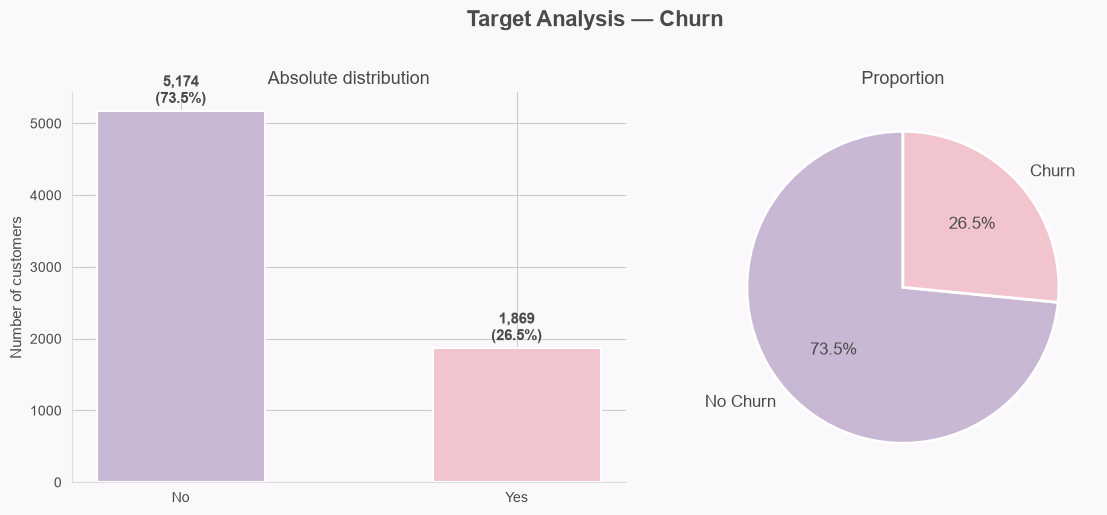

In [35]:
# Convert Churn to binary
df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)

churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Target distribution:")
print(pd.DataFrame({"count": churn_counts, "percentage": churn_pct.round(2)}))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=BACKGROUND)
fig.suptitle("Target Analysis — Churn", fontsize=16, fontweight="bold",
             color="#4A4A4A", y=1.02)

for ax in axes:
    ax.set_facecolor(BACKGROUND)

# Bar plot
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=COLORS, width=0.5, edgecolor="white", linewidth=1.5)
axes[0].set_title("Absolute distribution", fontsize=13, color="#4A4A4A")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of customers", fontsize=11, color="#4A4A4A")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].spines[["left", "bottom"]].set_color("#DDDDDD")
axes[0].tick_params(colors="#4A4A4A")
for bar, pct in zip(bars, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{bar.get_height():,.0f}\n({pct:.1f}%)',
                 ha='center', va='bottom', fontsize=11,
                 fontweight='bold', color="#4A4A4A")

# Pie chart
axes[1].pie(churn_counts.values, labels=["No Churn", "Churn"],
            colors=COLORS, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2),
            textprops={"fontsize": 12, "color": "#4A4A4A"})
axes[1].set_title("Proportion", fontsize=13, color="#4A4A4A")

plt.tight_layout()
plt.savefig("../data/processed/01_target_distribution.png", dpi=150,
            bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

### Findings
- **26.5% churn rate** — moderate class imbalance (73/27 ratio). Not extreme 
  but sufficient to impact model performance if left untreated
- With this imbalance, a model that always predicts "No churn" would achieve 
  73% accuracy — a completely misleading metric
- **Decision:** accuracy will not be used as the primary metric. 
  We will use **ROC-AUC, Precision, Recall and F1** on the minority class
- **Decision:** three strategies will be evaluated to handle imbalance:
  `class_weight='balanced'` in the model, SMOTE, and threshold tuning

## 3. Data Quality — TotalCharges
`TotalCharges` comes as `str` when it should be numeric.
This indicates non-numeric values (blank spaces) that pandas 
does not detect as nulls. We investigate how many there are 
and which customers are affected.

Rows with empty TotalCharges: 11

Affected customers detail:
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No

Nulls after conversion: 11


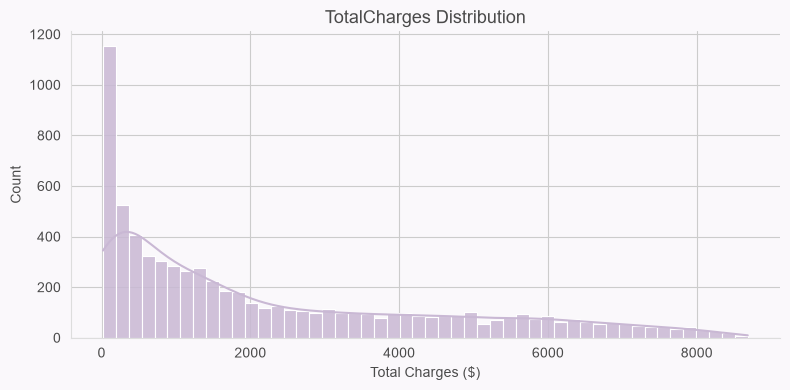

In [36]:
# Identify problematic values
total_charges_issues = df[df["TotalCharges"].str.strip() == ""]
print(f"Rows with empty TotalCharges: {len(total_charges_issues)}")
print(f"\nAffected customers detail:")
print(total_charges_issues[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

# Convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"\nNulls after conversion: {df['TotalCharges'].isna().sum()}")

# Distribution of cleaned TotalCharges
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BACKGROUND)
ax.set_facecolor(BACKGROUND)
sns.histplot(df["TotalCharges"].dropna(), bins=50, kde=True,
             color=SINGLE_COLOR, alpha=0.85, ax=ax)
ax.set_title("TotalCharges Distribution", fontsize=13, color="#4A4A4A")
ax.set_xlabel("Total Charges ($)", color="#4A4A4A")
ax.set_ylabel("Count", color="#4A4A4A")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#DDDDDD")
ax.tick_params(colors="#4A4A4A")
plt.tight_layout()
plt.savefig("../data/processed/02_totalcharges_distribution.png",
            dpi=150, bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

### Findings
- **11 rows** with empty TotalCharges — representing 0.15% of the dataset
- **Clear pattern:** all have `tenure = 0` → these are new customers who 
  have not yet generated any total charges in the system
- **This is not a data error** — it is a business case: customers who 
  have just signed up and whose first billing cycle has not yet closed
- TotalCharges distribution shows **right skew** — many customers with 
  low charges and few with very high charges, consistent with a mixed 
  customer base in terms of seniority

**Decision:** impute the 11 nulls with `0` — the most coherent decision 
given the business context (new customers with no accumulated charges), 
rather than median or mean imputation which would distort the real meaning.

In [37]:
# Business-justified imputation: new customers with tenure=0 → TotalCharges=0
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print(f"Nulls after imputation: {df['TotalCharges'].isna().sum()}")
print("Imputation complete — 11 new customers with TotalCharges=0")

Nulls after imputation: 0
Imputation complete — 11 new customers with TotalCharges=0


## 4. Numerical Variables
We analyse the three numerical variables in the dataset: `tenure`, 
`MonthlyCharges` and `TotalCharges`. The goal is to understand their 
distribution and relationship with churn.

C:\Users\dayana.alconz\AppData\Local\Temp\ipykernel_30308\1923478477.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=var,
C:\Users\dayana.alconz\AppData\Local\Temp\ipykernel_30308\1923478477.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=var,
C:\Users\dayana.alconz\AppData\Local\Temp\ipykernel_30308\1923478477.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=var,


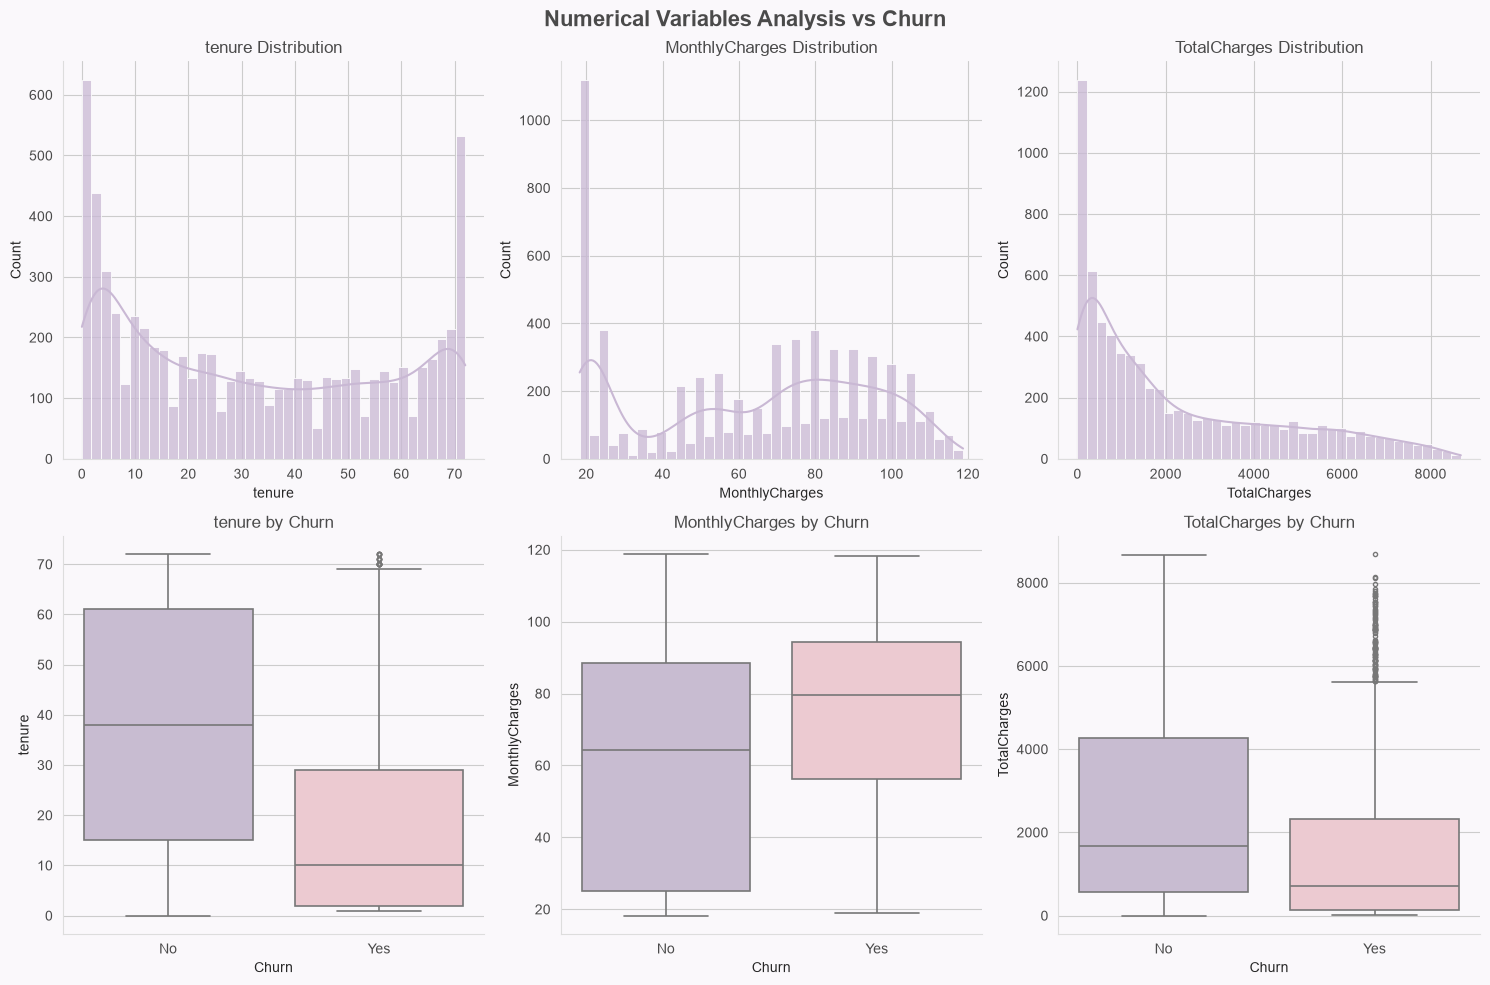


Median statistics by Churn group:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0           64.43       1679.52
Yes      10.0           79.65        703.55


In [38]:
num_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10), facecolor=BACKGROUND)
fig.suptitle("Numerical Variables Analysis vs Churn",
             fontsize=16, fontweight="bold", color="#4A4A4A")

for i, var in enumerate(num_vars):
    axes[0, i].set_facecolor(BACKGROUND)
    sns.histplot(data=df, x=var, bins=40, kde=True,
                 ax=axes[0, i], color=SINGLE_COLOR, alpha=0.75)
    axes[0, i].set_title(f"{var} Distribution", fontsize=12, color="#4A4A4A")
    axes[0, i].spines[["top", "right"]].set_visible(False)
    axes[0, i].spines[["left", "bottom"]].set_color("#DDDDDD")
    axes[0, i].tick_params(colors="#4A4A4A")

    axes[1, i].set_facecolor(BACKGROUND)
    sns.boxplot(data=df, x="Churn", y=var,
                ax=axes[1, i], palette=PALETTE,
                linewidth=1.2, flierprops=dict(marker='o', markersize=3,
                color="#AAAAAA"))
    axes[1, i].set_title(f"{var} by Churn", fontsize=12, color="#4A4A4A")
    axes[1, i].spines[["top", "right"]].set_visible(False)
    axes[1, i].spines[["left", "bottom"]].set_color("#DDDDDD")
    axes[1, i].tick_params(colors="#4A4A4A")

plt.tight_layout()
plt.savefig("../data/processed/03_numerical_variables.png", dpi=150,
            bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

# Median statistics by Churn group
print("\nMedian statistics by Churn group:")
print(df.groupby("Churn")[num_vars].median().round(2))

### Findings — Numerical Variables

**tenure (seniority):**
- Customers who do NOT churn have a median of ~38 months
- Customers who DO churn have a median of ~10 months
- **Conclusion:** new customers are the most vulnerable — 
  tenure is likely the most powerful predictor in the model

**MonthlyCharges (monthly charge):**
- Churned customers pay more per month (~$79) vs those who stay (~$65)
- **Conclusion:** higher monthly charges correlate with higher churn risk — 
  possibly related to more expensive Fiber optic contracts

**TotalCharges (total accumulated charges):**
- Churned customers have lower TotalCharges — a direct consequence 
  of being newer customers (fewer months × fewer accumulated charges)
- This variable has high correlation with tenure → potential multicollinearity

**Decision:** all three variables are predictive but TotalCharges 
is partially redundant with tenure. Its impact will be evaluated 
during feature selection at modelling stage.

## 5. Categorical Variables
We analyse how churn is distributed across categorical variables.
The goal is to identify which customer segments have the highest 
churn rate — this will guide subsequent feature engineering.

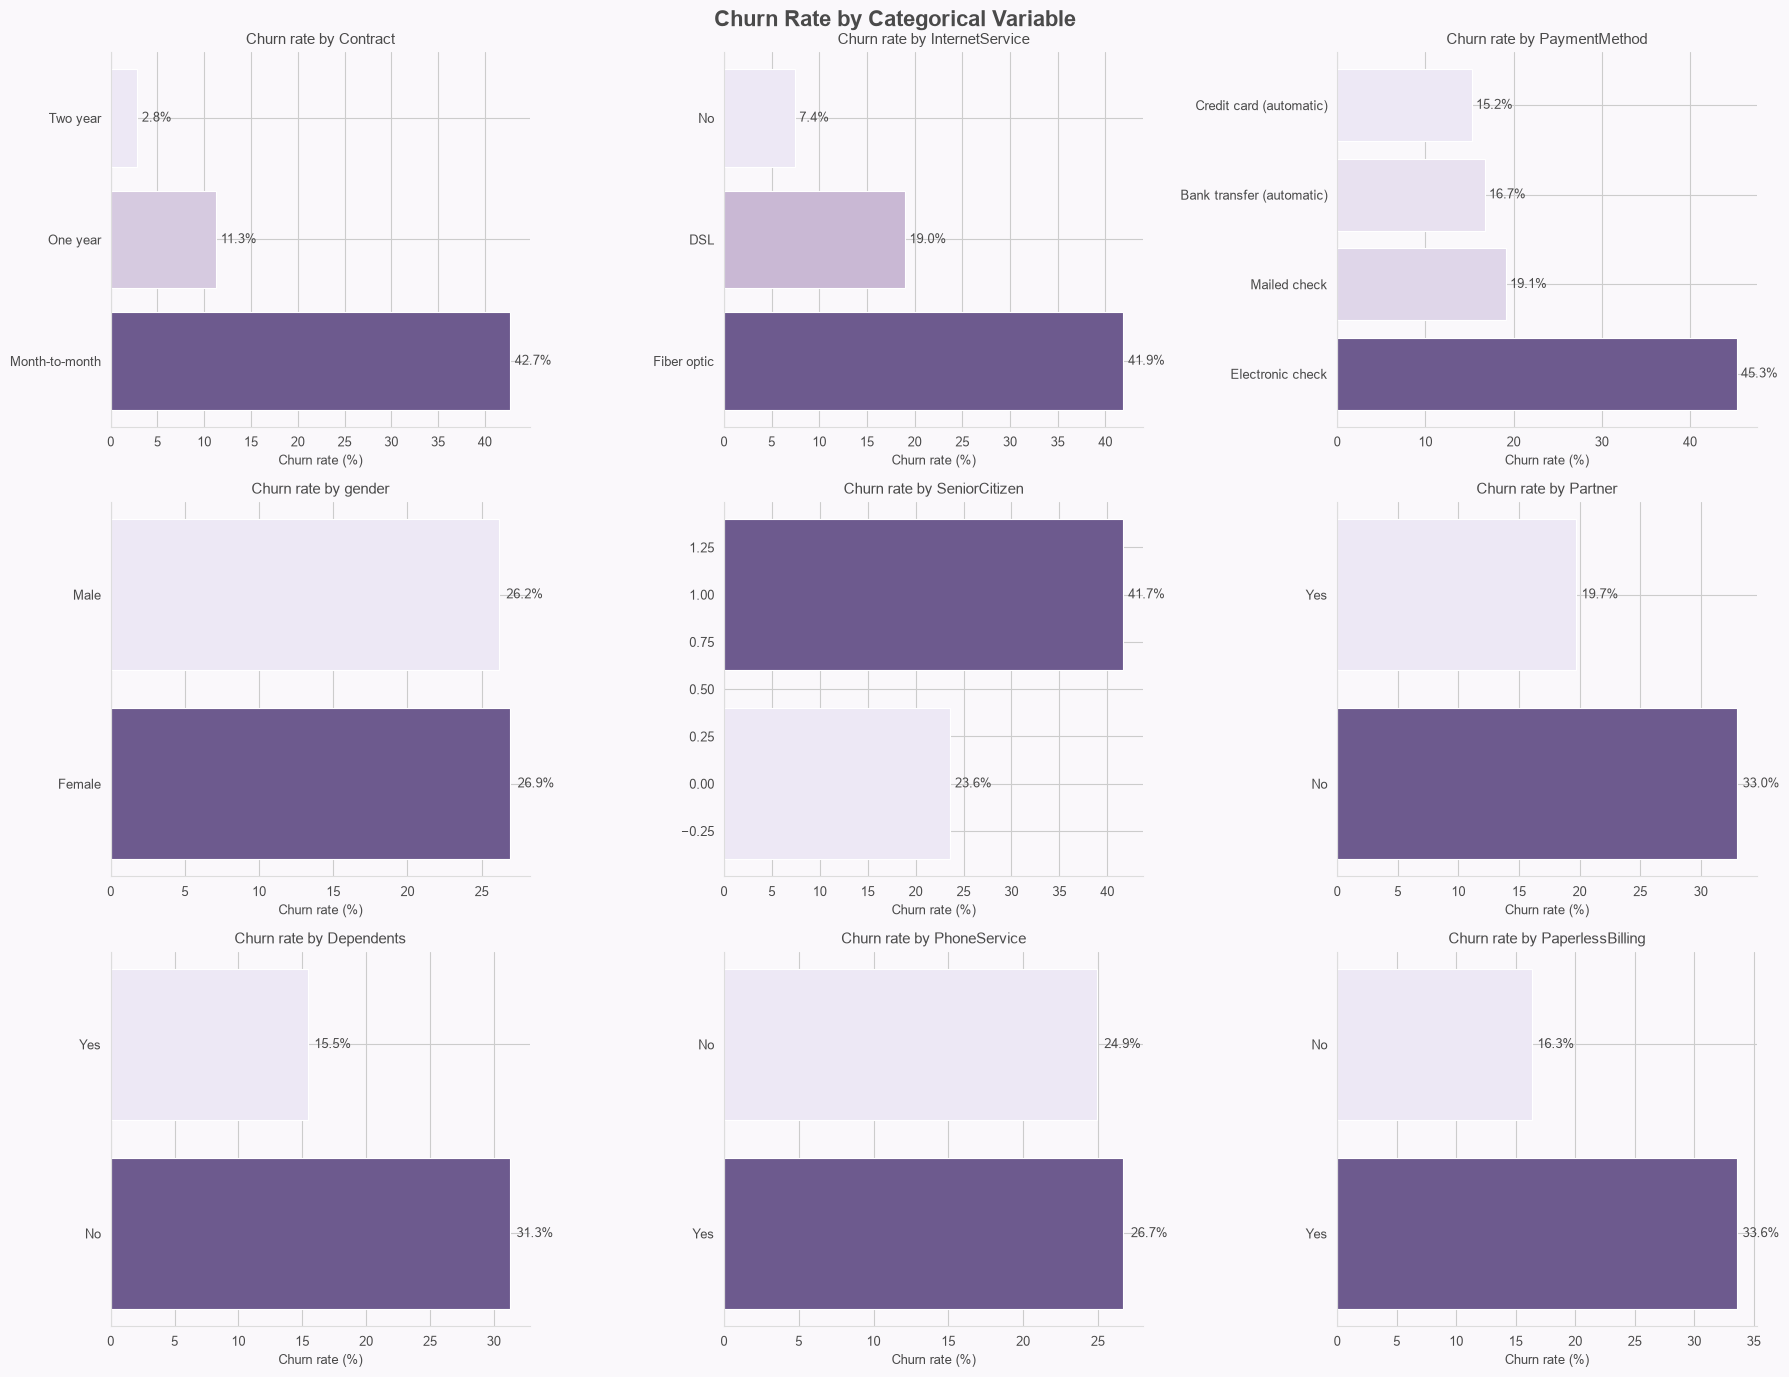


Churn rate by key categorical variable:

Contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8

InternetService:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4

PaymentMethod:
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1


In [39]:
from matplotlib.colors import LinearSegmentedColormap

cat_vars = ["Contract", "InternetService", "PaymentMethod",
            "gender", "SeniorCitizen", "Partner", "Dependents",
            "PhoneService", "PaperlessBilling"]

fig, axes = plt.subplots(3, 3, figsize=(18, 14), facecolor=BACKGROUND)
fig.suptitle("Churn Rate by Categorical Variable",
             fontsize=16, fontweight="bold", color="#4A4A4A")

axes = axes.flatten()

# Gradient in mauve-lavender family: light → dark
cmap = LinearSegmentedColormap.from_list("churn", ["#EDE8F5", "#C9B8D4", "#9B89B4", "#6D5A8E"])

for i, var in enumerate(cat_vars):
    churn_rate = df.groupby(var)["Churn_binary"].mean().sort_values(ascending=False) * 100

    norm_vals = (churn_rate.values - churn_rate.values.min()) / (churn_rate.values.max() - churn_rate.values.min() + 1e-9)
    colors_grad = [cmap(v) for v in norm_vals]

    bars = axes[i].barh(churn_rate.index, churn_rate.values,
                        color=colors_grad, edgecolor="white", linewidth=0.8)
    axes[i].set_facecolor(BACKGROUND)
    axes[i].set_title(f"Churn rate by {var}", fontsize=11, color="#4A4A4A")
    axes[i].set_xlabel("Churn rate (%)", color="#4A4A4A", fontsize=9)
    axes[i].spines[["top", "right"]].set_visible(False)
    axes[i].spines[["left", "bottom"]].set_color("#DDDDDD")
    axes[i].tick_params(colors="#4A4A4A", labelsize=9)

    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9, color="#4A4A4A")

plt.tight_layout()
plt.savefig("../data/processed/04_categorical_churn_rates.png",
            dpi=150, bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

# Churn rate for key categorical variables
print("\nChurn rate by key categorical variable:")
for var in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"\n{var}:")
    print((df.groupby(var)["Churn_binary"].mean() * 100).round(1).to_string())

### Findings — Categorical Variables

**Most predictive variables:**
- `Contract` — 40pp difference between month-to-month (43%) and two year (3%). 
  The most powerful categorical predictor in the dataset
- `PaymentMethod` — electronic check has the highest churn rate (45%). 
  Hypothesis: lower friction to cancel without a direct debit linked to a bank account
- `InternetService` — Fiber optic (~42%) doubles DSL (~19%). 
  Possibly related to higher price and stronger competition in that segment
- `SeniorCitizen` — customers over 65 have ~42% churn 
  vs 24% for the rest

**Moderately predictive variables:**
- `Partner` and `Dependents` — customers with family have ~15pp less churn. 
  Family responsibility acts as a retention anchor
- `PaperlessBilling` — digital profile more likely to compare offers and switch

**Non-significant variables:**
- `gender` and `PhoneService` — churn rate virtually identical 
  across categories. Low expected predictive value

**Decisions:**
- `Contract`, `InternetService` and `PaymentMethod` will be key features
- `gender` will be dropped in feature selection
- Combined features will be created: tenure × Contract, SeniorCitizen × InternetService

## 6. Correlation Matrix
We analyse correlations between numerical variables and the target
to confirm the relationships observed and detect multicollinearity.

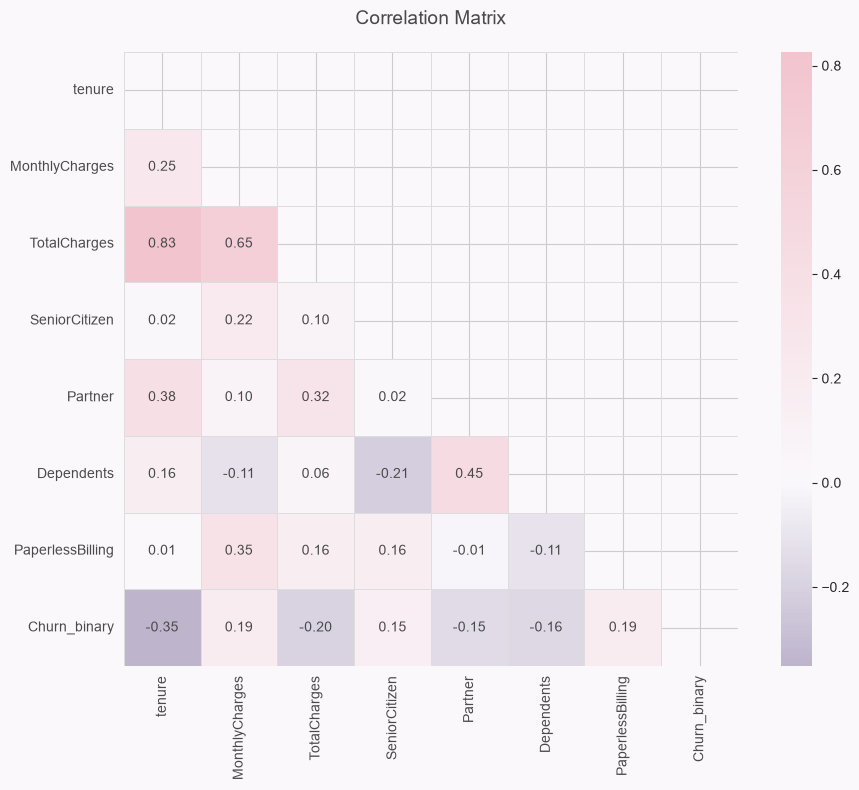


Correlations with Churn (sorted by absolute value):
tenure             -0.352
TotalCharges       -0.198
MonthlyCharges      0.193
PaperlessBilling    0.192
Dependents         -0.164
SeniorCitizen       0.151
Partner            -0.150
Name: Churn_binary, dtype: float64


In [43]:
# Prepare numeric data for correlation
df_corr = df.copy()

# Encode simple binary variables to include them
binary_map = {"Yes": 1, "No": 0}
for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]:
    df_corr[col] = df_corr[col].map(binary_map)

# Select numeric variables + target
corr_vars = ["tenure", "MonthlyCharges", "TotalCharges",
             "SeniorCitizen", "Partner", "Dependents",
             "PaperlessBilling", "Churn_binary"]

corr_matrix = df_corr[corr_vars].corr()

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8), facecolor=BACKGROUND)
ax.set_facecolor(BACKGROUND)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap=LinearSegmentedColormap.from_list("corr",
            ["#6D5A8E", "#FAF8FB", "#F2C4CE"]),
            center=0, square=True, linewidths=0.5,
            linecolor="#DDDDDD", ax=ax,
            annot_kws={"size": 10, "color": "#4A4A4A"})

ax.set_title("Correlation Matrix", fontsize=14,
             color="#4A4A4A", pad=20)
ax.tick_params(colors="#4A4A4A", labelsize=10)

plt.tight_layout()
plt.savefig("../data/processed/05_correlation_matrix.png",
            dpi=150, bbox_inches="tight", facecolor=BACKGROUND)
plt.show()

# Correlations with target sorted by absolute value
print("\nCorrelations with Churn (sorted by absolute value):")
print(corr_matrix["Churn_binary"].drop("Churn_binary")
      .sort_values(key=abs, ascending=False).round(3))

### Findings — Correlations

**Correlations with Churn:**
- `tenure` (-0.35) — strongest negative correlation: longer tenure, 
  less churn. Confirms it is the most powerful numerical predictor
- `MonthlyCharges` (0.19) — positive: higher monthly charge, more churn
- `TotalCharges` (-0.20) — negative but a consequence of tenure, 
  not an independent cause
- `SeniorCitizen` (0.15) — confirms the effect observed in categorical analysis

**Multicollinearity detected:**
- `TotalCharges` and `tenure` have very high correlation (~0.83)
- `TotalCharges` and `MonthlyCharges` also correlate (~0.65)
- **Decision:** evaluate dropping `TotalCharges` in favour of `tenure` 
  and `MonthlyCharges`, which are more interpretable and less redundant

**Variables with low correlation to Churn:**
- `Partner`, `Dependents`, `PaperlessBilling` — low individual correlation 
  but may have combined effect with other variables

## 7. Conclusions and Preprocessing Decisions

### Summary of Key Findings

**On the target:**
- Moderate 73/27 class imbalance — not critical but requires treatment
- Primary metric: ROC-AUC + F1 on the minority class.
  Accuracy discarded as primary metric

**On data quality:**
- 11 rows with empty TotalCharges → customers with tenure=0,
  imputed with 0 for business coherence
- No duplicates or other nulls found

**Most powerful predictors identified:**
1. `tenure` — most important numerically (corr -0.35)
2. `Contract` — 40pp difference between contract types
3. `InternetService` — Fiber optic doubles DSL churn rate
4. `PaymentMethod` — electronic check with highest churn rate
5. `MonthlyCharges` — higher charge, higher risk

**Low predictive value variables:**
- `gender` — identical churn rate across categories
- `customerID` — identifier, will be dropped

---

### Preprocessing Decisions

| Decision | Justification |
|---|---|
| Drop `customerID` | Identifier with no predictive value |
| Drop `gender` | No significant difference in churn rate |
| Impute `TotalCharges` nulls with 0 | New customers with no accumulated charges |
| Convert `TotalCharges` to numeric | Came as string due to blank spaces |
| Ordinal encoding for `Contract` | Natural order: month < one year < two year |
| One-hot encoding for remaining categoricals | No natural order |
| Evaluate dropping `TotalCharges` | High multicollinearity with tenure (0.83) |
| `class_weight='balanced'` as baseline | Simplest strategy for class imbalance |
| Threshold tuning post-training | Optimise based on business cost of FP vs FN |

---

### Next Steps
1. **Preprocessing pipeline** — implement all decisions above
   in `src/churn_pipeline/data/preprocessing.py`
2. **Feature engineering** — create combined features:
   - `tenure_group` — segment tenure into business groups
   - `services_count` — total number of contracted services
   - `is_fiber_monthly` — Fiber optic × MonthlyCharges interaction
3. **Modelling** — baseline logistic regression → XGBoost with MLflow tracking